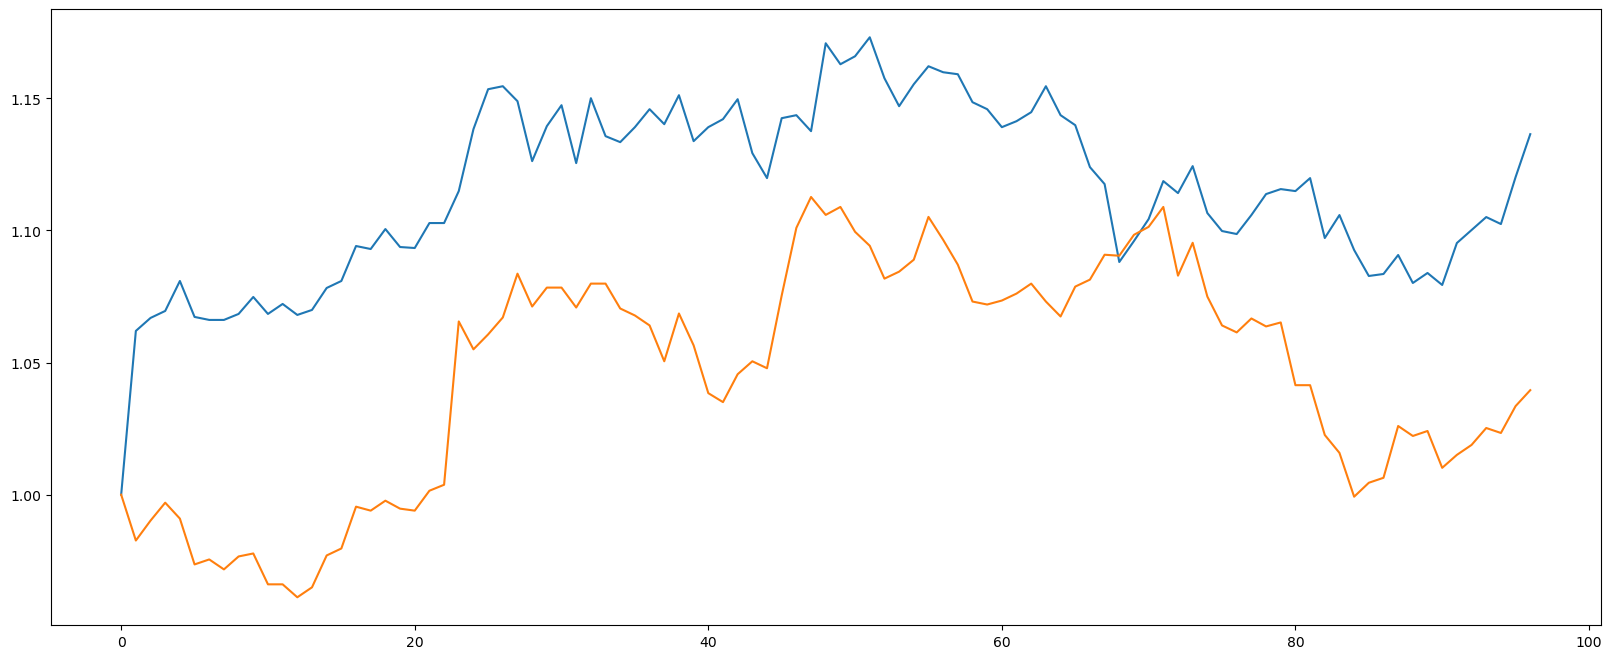

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm

df = pd.read_csv('market_price.csv')
asset_1 = "ao2402"
asset_2 = "ru2405"
asset_1_values = df[asset_1].values / df[asset_1].iloc[0].item()
asset_2_values = df[asset_2].values / df[asset_2].iloc[0].item()
plt.figure(1, figsize=(20, 8))
plt.plot(asset_1_values)
plt.plot(asset_2_values)
plt.show()

0.21270349800081867
3.0
zscore: 0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
        ...   
92    0.958254
93    0.794899
94    0.696383
95    0.973036
96    1.405579
Length: 97, dtype: float64


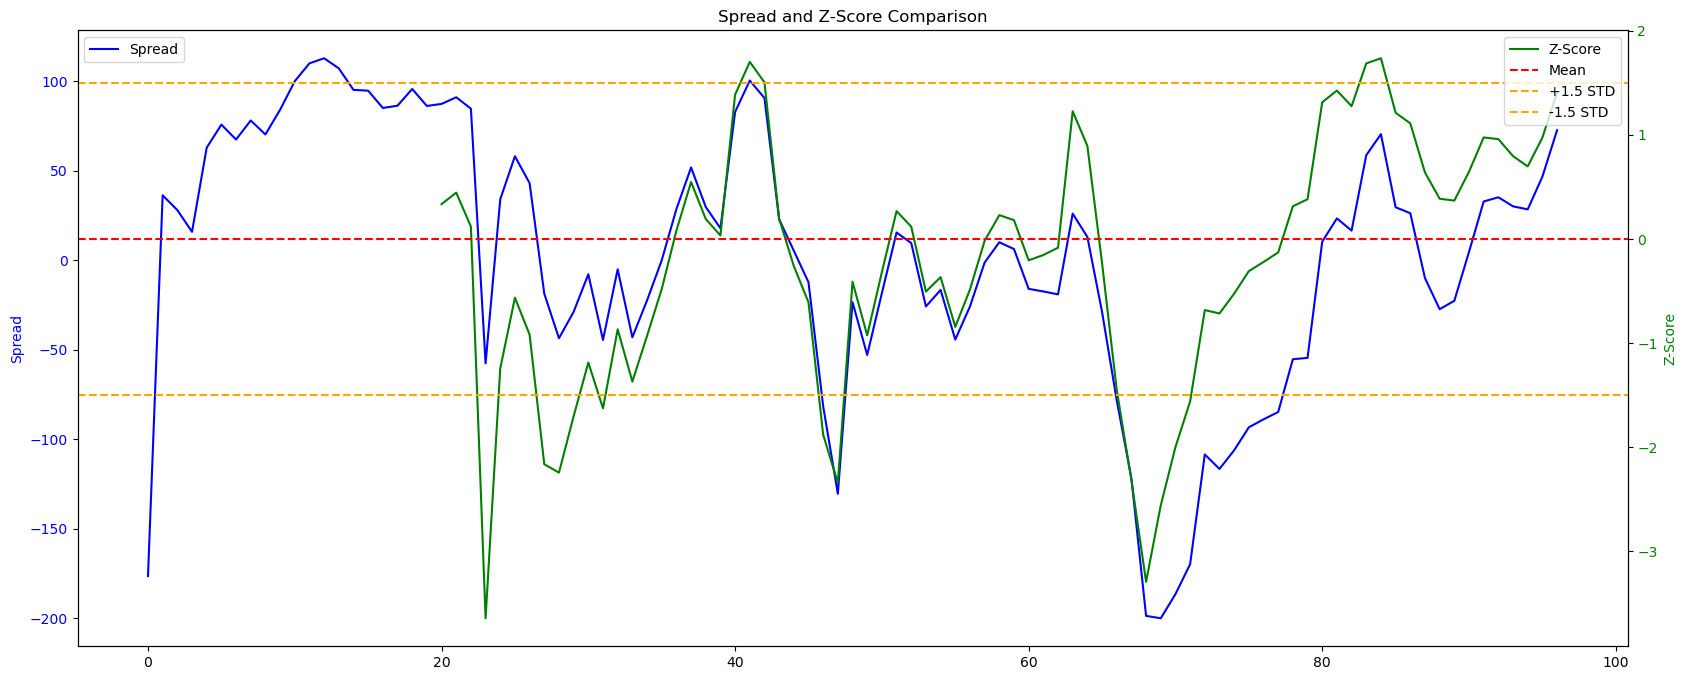

In [7]:
# Calculate cointegration
def calculate_cointegration(series_1, series_2):
    coint_flag = 0
    coint_res = coint(series_1, series_2)
    coint_t = coint_res[0]
    p_value = coint_res[1]
    critical_value = coint_res[2][1]
    model = sm.OLS(series_1, series_2).fit()
    hedge_ratio = model.params[0]
    coint_flag = 1 if p_value < 0.05 and coint_t < critical_value else 0
    return coint_flag, hedge_ratio
# calculate zscore
def calculate_zscore(spread):
    spread_series = pd.Series(spread)
    mean = spread_series.rolling(center=False, window=21).mean()
    std = spread_series.rolling(center=False, window=21).std()
    x = spread_series.rolling(center=False, window=1).mean()
    zscore = (x-mean) / std
    return zscore
def calculate_half_life(spread):
    df_spread = pd.DataFrame(spread, columns=["spread"])
    spread_lag = df_spread.spread.shift(1)
    spread_lag.iloc[0] = spread_lag.iloc[1]
    spread_ret = df_spread.spread - spread_lag
    
    spread_ret.iloc[0] = spread_ret.iloc[1]
    spread_lag2 = sm.add_constant(spread_lag)
    model = sm.OLS(spread_ret,spread_lag2)
    res  = model.fit()
    halflife = round(-np.log(2)/ res.params[1], 0)
    return halflife
# Plot the Spread
series_1 = df[asset_1].values.astype(float)
series_2 = df[asset_2].values.astype(float)
coint_flag, hedge_ratio = calculate_cointegration(series_1, series_2)
print(hedge_ratio)
spread = series_1 - (hedge_ratio * series_2)
half_life  = calculate_half_life(spread)
print(half_life)

# Calculate z-score for the spread
zscore = calculate_zscore(spread)
print(f"zscore: {zscore[-1]}")

# Plotting the spread
plt.figure(1, figsize=(20, 8))
ax1 = plt.gca()  # Get the current Axes instance
ax1.plot(spread, color='blue', label='Spread')
ax1.set_ylabel('Spread', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

# Create a second y-axis for z-score
ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
ax2.plot(zscore, color='green', label='Z-Score')
ax2.axhline(y=0, color='r', linestyle='--', label='Mean')
ax2.axhline(y=1.5, color='orange', linestyle='--', label='+1.5 STD')
ax2.axhline(y=-1.5, color='orange', linestyle='--', label='-1.5 STD')
ax2.set_ylabel('Z-Score', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc='upper right')

plt.title('Spread and Z-Score Comparison')
plt.show()